<a href="https://colab.research.google.com/github/AbubakkarAslam/Deep-Learning-Journey/blob/main/05_image_classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import PIL
import shutil
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.models import Sequential
import os
import pathlib


In [84]:
# lets load the dataset of images from tensorflow
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
dataset = tf.keras.utils.get_file("flower_photos.tgz", origin=dataset_url, extract=True, untar=True, cache_dir='.', cache_subdir='')
# data_dir = pathlib.Path(data_dir).parent / "flower_photos_extracted" / "flower_photos"
dataset_dir = os.path.join(os.path.dirname(dataset), 'flower_photos_extracted/flower_photos')

In [85]:
# Lets see how many directories insie the dataset
print(os.listdir(dataset_dir))

['roses', 'LICENSE.txt', 'dandelion', 'daisy', 'tulips', 'sunflowers']


In [86]:
import pathlib
# Check how many data of flower in the dataset
image_count = len(list(pathlib.Path(dataset_dir).glob("*/*.jpg")))
print(image_count)

3670


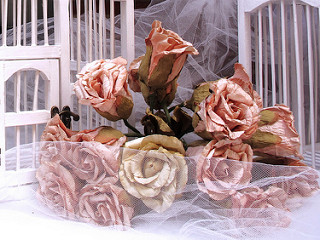

In [87]:
# Print some roses flower
rose = list(pathlib.Path(dataset_dir).glob("roses/*"))
# for i in range(3):
#  display(PIL.Image.open(str(rose[i])))


# secound: if one image want to show
PIL.Image.open(str(rose[1]))

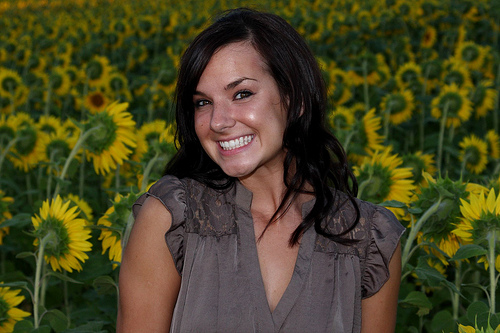

In [88]:
# Print some sunflowers flower
sunflowers = list(pathlib.Path(dataset_dir).glob("sunflowers/*"))
# for i in range(3):
#   display(PIL.Image.open(str(sunflowers[i])))

PIL.Image.open(str(sunflowers[1]))

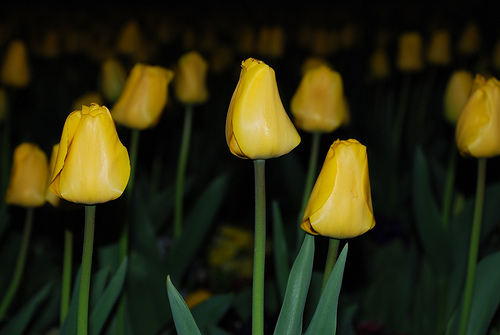

In [89]:
tulips = list(pathlib.Path(dataset_dir).glob('tulips/*'))

# for i in range(3):
#   display(PIL.Image.open(str(tulips[i])))



PIL.Image.open(str(tulips[1]))

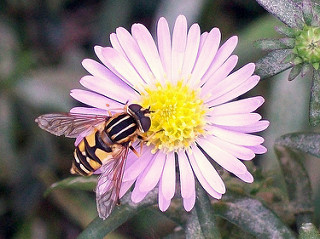

In [90]:
# Display the daisy image
daisy = list(pathlib.Path(dataset_dir).glob('daisy/*'))
# for i in range(3):
#   display(PIL.Image.open(str(daisy[i])))


PIL.Image.open(str(daisy[1]))

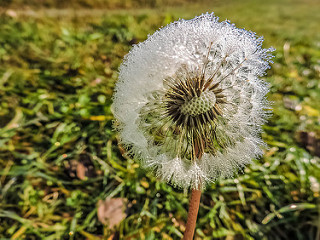

In [91]:
# Display the dandelion images
dandelion = list(pathlib.Path(dataset_dir).glob('dandelion/*'))

# for i in range(3):
#   display(PIL.Image.open(str(dandelion[i])))



PIL.Image.open(str(dandelion[1]))

In [92]:
import os

# Get class names from the subdirectories in dataset_dir
class_names = keras.utils.image_dataset_from_directory(dataset_dir)
print(class_names)

Found 3670 files belonging to 5 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Load the dataset by using the keras utils

In [93]:
# first declair the batch_size, image_height, image_width

batch_size = 32
img_height = 180
img_width = 180

In [94]:
# split the data into train and validation by validatio_split
# This is for training the data
train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='training',
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [95]:
# This is for validation
val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='validation',
    seed = 123,
    batch_size=batch_size,
    image_size=(img_height, img_width)
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


You can find the class names in the `class_names` attribute on these datasets. These correspond to the directory names in alphabetical order.

In [96]:
train_class_names = train_ds.class_names
print(train_class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Visualize the data

Here are the first nine images from the training dataset:

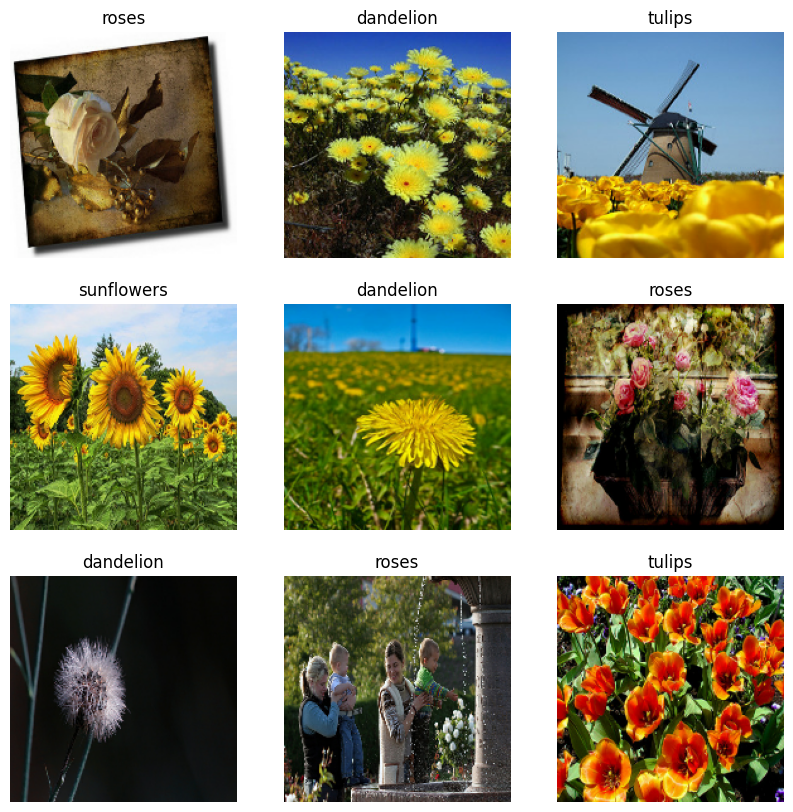

In [97]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_class_names[labels[i]])
    plt.axis("off")

In [112]:
# Now check the shape of the training data
for batch, label in train_ds:
  print(batch.shape)
  print(label.shape)

  break

(32, 180, 180, 3)
(32,)


- `Dataset.cache` keeps the images in memory after they're loaded off disk during the first epoch. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache.
- `Dataset.prefetch` overlaps data preprocessing and model execution while training.

In [113]:
# Autotune  the data and load in cache
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


## Standardize the data


The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small.

Here, you will standardize values to be in the `[0, 1]` range by using `tf.keras.layers.Rescaling`:

In [114]:
normalizer = layers.Rescaling(1./255)

In [118]:
num_classes = len(class_names)
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='softmax'),
    layers.Dense(num_classes)

])

### Compile the model

Choose the `tf.keras.optimizers.Adam` optimizer and `tf.keras.losses.SparseCategoricalCrossentropy` loss function. To view training and validation accuracy for each training epoch, pass the `metrics` argument to `Model.compile`.

In [119]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics = ['accuracy'])

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 115)            │        14,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,003,475 (15.27 MB)

 Trainable params: 4,003,475 (15.27 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model
Train the model for 10 epochs with the Keras `Model.fit` method:

---



In [120]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1706 - loss: 4.4824 - val_accuracy: 0.1757 - val_loss: 4.3084
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1717 - loss: 4.1439 - val_accuracy: 0.1757 - val_loss: 3.9817
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1717 - loss: 3.8261 - val_accuracy: 0.1757 - val_loss: 3.6732
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1993 - loss: 3.5275 - val_accuracy: 0.2398 - val_loss: 3.3858
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2241 - loss: 3.2525 - val_accuracy: 0.2139 - val_loss: 3.1236
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2442 - loss: 3.0038 - val_accuracy: 0.2398 - val_loss: 2.8894
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2459 - loss: 2.7845 - val_accuracy: 0.2398 - val_loss: 2.6854
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2459 - loss: 2.5956 - val_accuracy: 0.2398 - v

## Visualize training results

Create plots of the loss and accuracy on the training and validation sets:

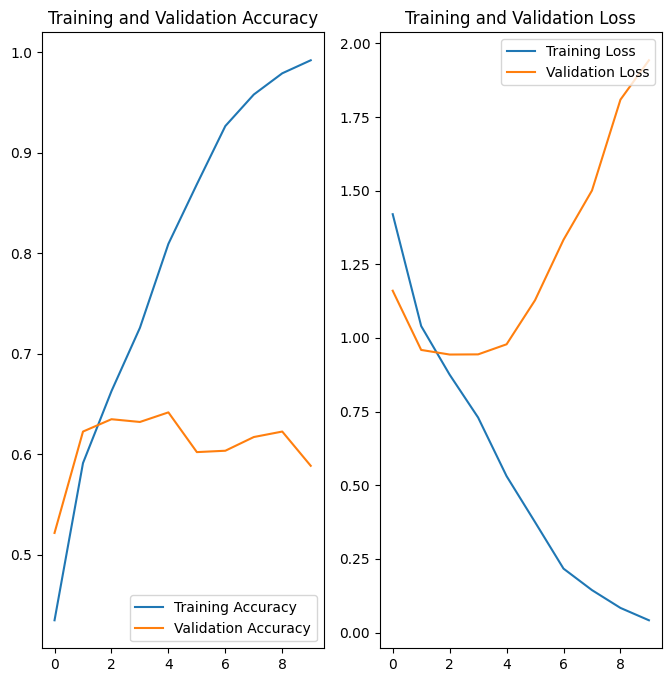

In [104]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Overfitting

In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process. Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of [overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).

When there are a small number of training examples, the model sometimes learns from noises or unwanted details from training examples—to an extent that it negatively impacts the performance of the model on new examples. This phenomenon is known as overfitting. It means that the model will have a difficult time generalizing on a new dataset.

There are multiple ways to fight overfitting in the training process. In this tutorial, you'll use *data augmentation* and add *dropout* to your model.

## Data augmentation

Overfitting generally occurs when there are a small number of training examples. `Data augmentation` takes the approach of generating additional training data from your existing examples by augmenting them using random transformations that yield believable-looking images. This helps expose the model to more aspects of the data and generalize better.

You will implement data augmentation using the following Keras preprocessing layers: `tf.keras.layers.RandomFlip`, `tf.keras.layers.RandomRotation`, and `tf.keras.layers.RandomZoom`. These can be included inside your model like other layers, and run on the GPU.

In [121]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal', input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)

])

## Data Augmentation Visualization

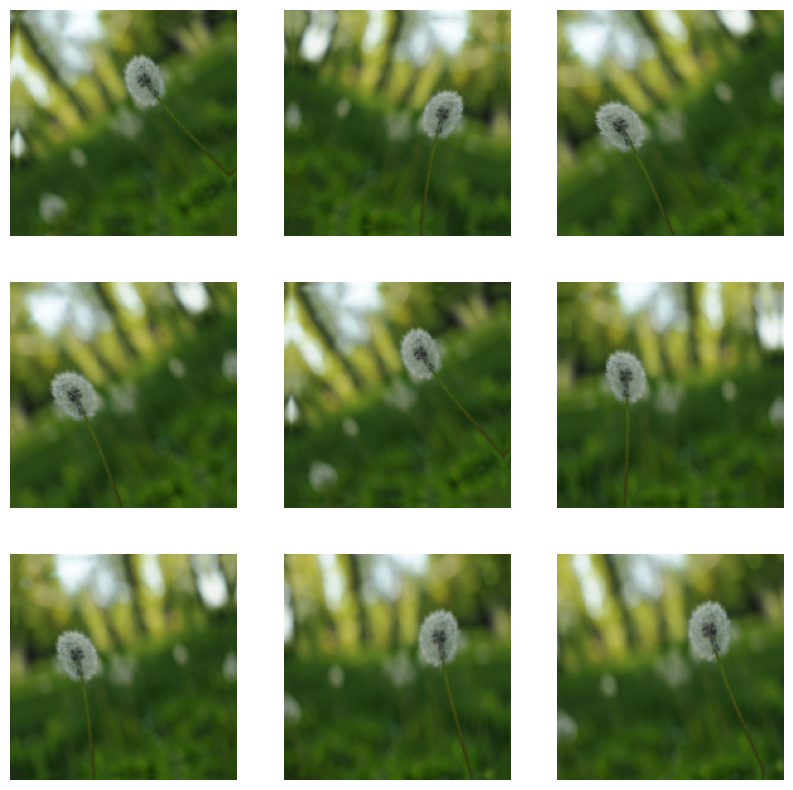

In [122]:

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

We will add data augmentation to your model before training in the next step.

## Dropout

Another technique to reduce overfitting is to introduce dropout regularization to the network.

When you apply dropout to a layer, it randomly drops out (by setting the activation to zero) a number of output units from the layer during the training process. Dropout takes a fractional number as its input value, in the form such as 0.1, 0.2, 0.4, etc. This means dropping out 10%, 20% or 40% of the output units randomly from the applied layer.

Create a new neural network with `tf.keras.layers.Dropout` before training it using the augmented images:

## Create the model with adding the Data Augmentation

In [123]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='softmax'),
    layers.Dense(num_classes, name='outputs')
])

In [124]:
model.compile(optimizer='adam', loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [125]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2302 - loss: 4.4982 - val_accuracy: 0.1771 - val_loss: 4.3160
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1747 - loss: 4.1394 - val_accuracy: 0.2398 - val_loss: 3.9639
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2459 - loss: 3.8038 - val_accuracy: 0.2398 - val_loss: 3.6441
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2459 - loss: 3.4973 - val_accuracy: 0.2398 - val_loss: 3.3512
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2459 - loss: 3.2183 - val_accuracy: 0.2398 - val_loss: 3.0871
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2459 - loss: 2.9695 - val_accuracy: 0.2398 - val_loss: 2.8535
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2459 - loss: 2.7514 - val_accuracy: 0.2398 - val_loss: 2.6517
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2459 - loss: 2.5651 - val_accuracy: 0.2398 - v

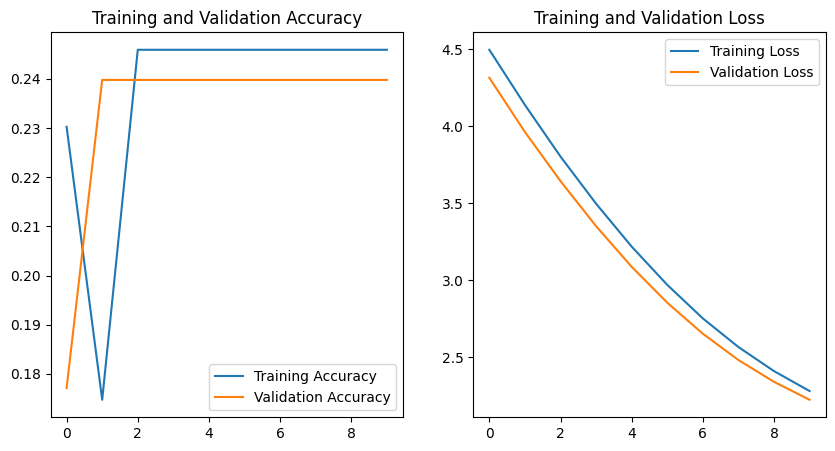

In [126]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Predict on new data



In [128]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(train_class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
This image most likely belongs to dandelion with a 11.75 percent confidence.
